In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Plotting and ANOVA

In [4]:
#Load data
adata_combined = sc.read_h5ad("/home/philm12/lab-website/PseudobulkCounts.h5ad")


In [5]:
def plot_gene_expression(adata_combined, gene_of_interest, subset_conditions=None, plot_conditions=['DiseaseState']):
    """
    Plots gene expression based on subset conditions and groups by multiple categorical variables.
    Performs ANOVA and Tukey's post-hoc test to identify significant differences.

    Parameters:
    adata_combined: AnnData object
    gene_of_interest: str, gene name to plot
    subset_conditions: dict, conditions to subset the data (e.g., {'Sex': 'F', 'DiseaseState': 'OldCtrl'})
    plot_conditions: list of str, columns in 'obs' to group by and plot (e.g., ['Sex', 'CellType', 'DiseaseState'])
    """
    # Apply subset conditions to filter the AnnData object
    if subset_conditions:
        for key, value in subset_conditions.items():
            adata_combined = adata_combined[adata_combined.obs[key] == value]

    # Extract the counts matrix for the filtered data (pseudobulk RNA counts)
    counts_matrix = adata_combined.X.T

    # Normalize each sample (column) by dividing by the total sum of counts in that column
    normalized_counts = counts_matrix / counts_matrix.sum(axis=0)

    # Convert to a pandas DataFrame for easy handling
    normalized_counts_df = pd.DataFrame(normalized_counts, index=adata_combined.var_names, columns=adata_combined.obs_names)

    # Extract normalized counts for the gene of interest
    gene_counts = normalized_counts_df.loc[gene_of_interest]

    # Add metadata to the gene counts
    gene_counts_df = pd.DataFrame({"counts": gene_counts})
    
    # Add the relevant plot conditions to the dataframe
    for condition in plot_conditions:
        gene_counts_df[condition] = adata_combined.obs[condition]

    # Apply log transformation (log base 10) to the counts
    gene_counts_df['log_counts'] = np.log10(gene_counts_df['counts'] + 1)  # Avoid log(0)

    # Combine the categorical variables into a single column for grouping
    gene_counts_df['Group'] = gene_counts_df[plot_conditions].astype(str).agg(' | '.join, axis=1)

    # Perform ANOVA across groups
    groups = [group['log_counts'].dropna().values for _, group in gene_counts_df.groupby('Group')]
    
    if len(groups) > 1:  # ANOVA requires at least 2 groups
        anova_stat, p_value = stats.f_oneway(*groups)
    else:
        p_value = np.nan  # Not enough groups for ANOVA

    # Perform Tukey's post-hoc test if ANOVA is significant
    tukey_results = None
    significant_pairs = []
    if not np.isnan(p_value) and p_value < 0.05:
        tukey_results = pairwise_tukeyhsd(gene_counts_df['log_counts'], gene_counts_df['Group'])
        tukey_df = pd.DataFrame(data=tukey_results.summary().data[1:], columns=tukey_results.summary().data[0])

        # Filter significant comparisons (p < 0.05)
        significant_pairs = tukey_df[tukey_df['p-adj'] < 0.05][['group1', 'group2', 'p-adj']].values

    # Plot the gene expression (log-transformed counts) across the combined categories
    plt.figure(figsize=(12,6))

    # Create a boxplot to show distribution with individual points
    sns.boxplot(data=gene_counts_df, x="Group", y="log_counts", linewidth=1)

    # Overlay individual points on the boxplot
    sns.stripplot(data=gene_counts_df, x="Group", y="log_counts", color='black', alpha=0.6, jitter=True)

    # Add title and labels
    plt.title(f"Log10 Normalized Expression of {gene_of_interest}")
    #plt.xlabel("Group ( | separated)")
    plt.ylabel("Log10(Normalized Counts)")
    
    # Rotate labels perpendicular (90 degrees)
    plt.xticks(rotation=90)

    # Display p-value if ANOVA was performed
    if not np.isnan(p_value):
        plt.figtext(0.15, 0.85, f"ANOVA p-value: {p_value:.4e}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # Print ANOVA results
    print(f"ANOVA p-value for {gene_of_interest}: {p_value:.4e}")

    # Print post-hoc results if significant
    if len(significant_pairs) > 0:
        print("\nSignificant post-hoc comparisons (Tukey’s HSD test):")
        for group1, group2, p_adj in significant_pairs:
            print(f"{group1} vs {group2}: p={p_adj:.4e}")

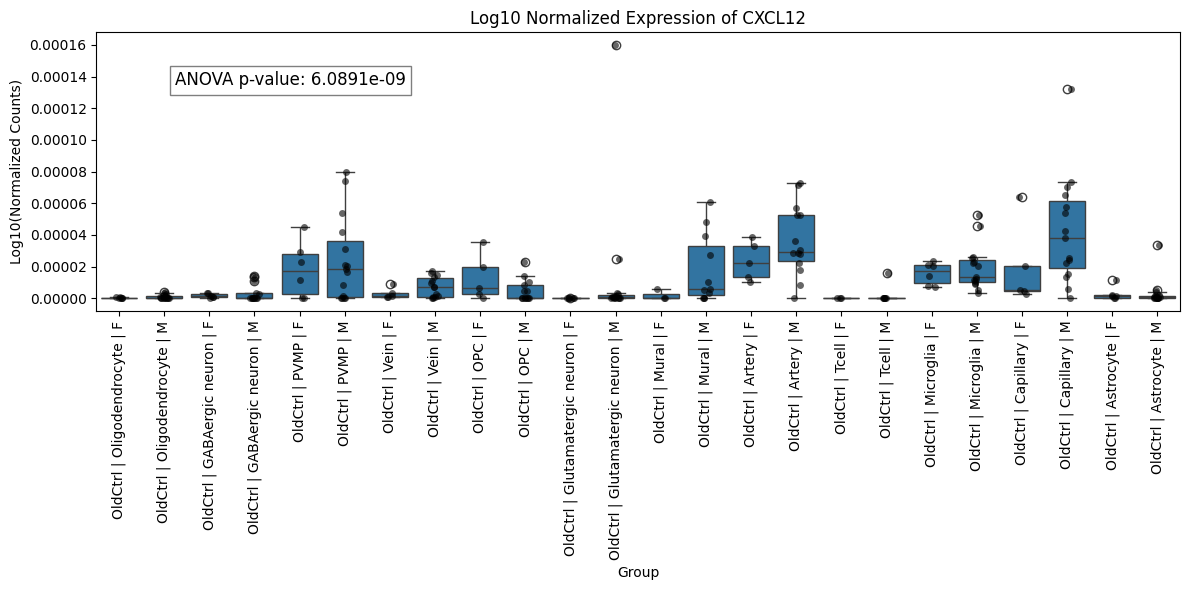

ANOVA p-value for CXCL12: 6.0891e-09

Significant post-hoc comparisons (Tukey’s HSD test):
OldCtrl | Artery | M vs OldCtrl | Astrocyte | M: p=1.5000e-03
OldCtrl | Artery | M vs OldCtrl | GABAergic neuron | F: p=4.6800e-02
OldCtrl | Artery | M vs OldCtrl | GABAergic neuron | M: p=3.3000e-03
OldCtrl | Artery | M vs OldCtrl | Glutamatergic neuron | F: p=2.7500e-02
OldCtrl | Artery | M vs OldCtrl | OPC | M: p=7.3000e-03
OldCtrl | Artery | M vs OldCtrl | Oligodendrocyte | F: p=2.8800e-02
OldCtrl | Artery | M vs OldCtrl | Oligodendrocyte | M: p=4.0000e-04
OldCtrl | Artery | M vs OldCtrl | Tcell | M: p=3.1000e-02
OldCtrl | Artery | M vs OldCtrl | Vein | M: p=1.7200e-02
OldCtrl | Astrocyte | F vs OldCtrl | Capillary | M: p=5.4000e-03
OldCtrl | Astrocyte | M vs OldCtrl | Capillary | M: p=0.0000e+00
OldCtrl | Capillary | M vs OldCtrl | GABAergic neuron | F: p=3.3000e-03
OldCtrl | Capillary | M vs OldCtrl | GABAergic neuron | M: p=0.0000e+00
OldCtrl | Capillary | M vs OldCtrl | Glutamatergic neur

In [6]:
# Example Usage
subset_conditions = {'DiseaseState': 'OldCtrl'}  # Filter only for 'OldCtrl'
plot_conditions = ['DiseaseState', 'CellType', 'Sex']  # Group by multiple conditions

# Call the function for a gene of interest (e.g., CXCL12)
plot_gene_expression(adata_combined, gene_of_interest="CXCL12", subset_conditions=subset_conditions, plot_conditions=plot_conditions)


In [7]:
for col in adata_combined.obs.columns:
    unique_values = adata_combined.obs[col].unique()
    print(f"{col}: {unique_values}")


SampleID: ['845', '1081', '5952', '5740', '6314', ..., '5598', '6270', '4737', '5549', '1429']
Length: 92
Categories (92, object): ['689', '845', '925', '946', ..., '6342', '6350', '6371', '-3461']
DiseaseState: ['ALS', 'OldCtrl', 'YngCtrl', 'FTD', 'AD']
Categories (5, object): ['AD', 'ALS', 'FTD', 'OldCtrl', 'YngCtrl']
Sex: ['F', 'M']
Categories (2, object): ['F', 'M']
CellType: ['Oligodendrocyte', 'GABAergic neuron', 'PVMP', 'Vein', 'OPC', ..., 'Artery', 'Tcell', 'Microglia', 'Capillary', 'Astrocyte']
Length: 12
Categories (12, object): ['Artery', 'Astrocyte', 'Capillary', 'GABAergic neuron', ..., 'Oligodendrocyte', 'PVMP', 'Tcell', 'Vein']
batch: ['Feb2_2022', 'Jan18_2023', 'Jan24A_2023', 'Mar16A_2022', 'Mar21_2022', ..., 'Jan19A_2023', 'Jan19B_2023', 'Jan25_2023', 'Mar24A_2022', 'Jan12_2023']
Length: 25
Categories (25, object): ['Dec22_2022', 'Feb2_2022', 'Jan9_2023', 'Jan11_2023', ..., 'Mar24A_2022', 'Mar24B_2022', 'Oct10_2022', 'Oct19_2022']


In [8]:
for col in adata_combined.obs.columns:
    if adata_combined.obs[col].dtype.name == "category":
        print(f"{col}: {list(adata_combined.obs[col].cat.categories)}")
    else:
        print(f"{col}: {adata_combined.obs[col].unique().tolist()}")

SampleID: ['689', '845', '925', '946', '1016', '1025', '1026', '1081', '1259', '1312', '1429', '1439', '1486', '1630', '1705', '1710', '1712', '1720', '1819', '1843', '4513', '4522', '4535', '4559', '4587', '4600', '4632', '4641', '4737', '4762', '4872', '4916', '4921', '4976', '5000', '5028', '5082', '5089', '5125', '5148', '5151', '5171', '5195', '5222', '5242', '5337', '5344', '5352', '5388', '5390', '5497', '5501', '5511', '5525', '5532', '5549', '5575', '5580', '5598', '5602', '5657', '5661', '5675', '5678', '5680', '5697', '5729', '5732', '5740', '5823', '5824', '5830', '5840', '5951', '5952', '5954', '6019', '6044', '6047', '6054', '6096', '6101', '6199', '6207', '6270', '6314', '6316', '6332', '6342', '6350', '6371', '-3461']
DiseaseState: ['AD', 'ALS', 'FTD', 'OldCtrl', 'YngCtrl']
Sex: ['F', 'M']
CellType: ['Artery', 'Astrocyte', 'Capillary', 'GABAergic neuron', 'Glutamatergic neuron', 'Microglia', 'Mural', 'OPC', 'Oligodendrocyte', 'PVMP', 'Tcell', 'Vein']
batch: ['Dec22_2022